<a href="https://colab.research.google.com/github/Vedansh5674/data-analytics-task-python-Jupyter-Notebook/blob/main/Level_2_Task_3_Cuisine_Combination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("Dataset .csv")

# View columns
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [3]:
df = df[['Cuisines', 'Aggregate rating']]

In [4]:
# Remove Missing Values
df.dropna(inplace=True)

/tmp/ipykernel_13035/4053217395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [5]:
# Find Most Common Cuisine Combinations
# Count cuisine combinations
cuisine_counts = df['Cuisines'].value_counts()

# Top 10 combinations
top_combinations = cuisine_counts.head(10)

print(top_combinations)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


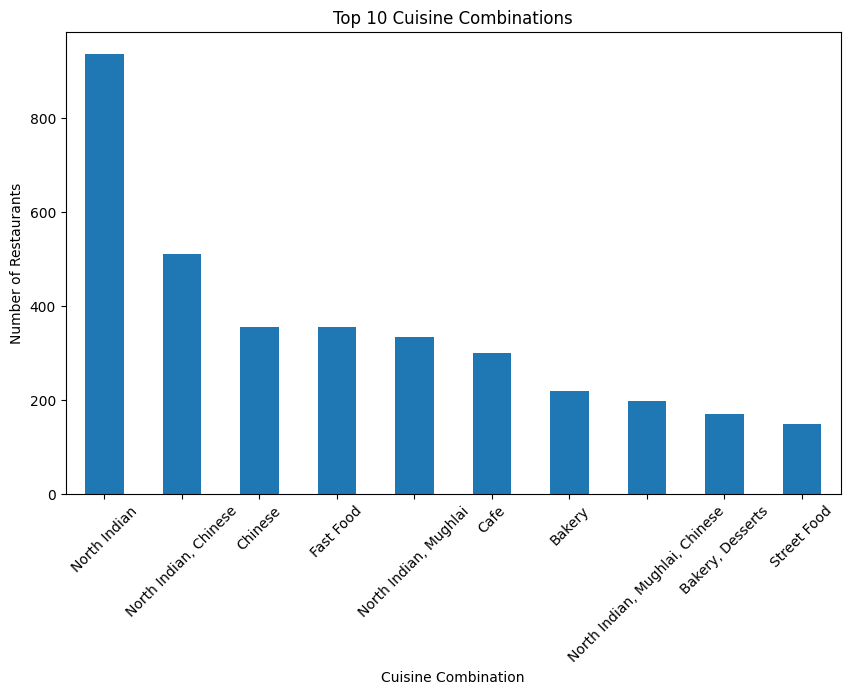

In [6]:
# Plot Most Common Cuisine Combinations
import matplotlib.pyplot as plt

top_combinations.plot(kind='bar', figsize=(10,6))

plt.title("Top 10 Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.show()

In [7]:
# Find Average Ratings of Cuisine Combinations
avg_ratings = df.groupby('Cuisines')['Aggregate rating'].mean()

In [8]:
# Combine Count + Ratings
result = pd.DataFrame({
    'Count': df['Cuisines'].value_counts(),
    'Average Rating': avg_ratings
})

# Sort by rating
result = result.sort_values(by='Average Rating', ascending=False)

print(result.head(10))

                                 Count  Average Rating
Cuisines                                              
Burger, Bar Food, Steak              1             4.9
American, Burger, Grill              1             4.9
American, Caribbean, Seafood         1             4.9
American, Coffee and Tea             1             4.9
Mexican, American, Healthy Food      1             4.9
Italian, Bakery, Continental         1             4.9
BBQ, Breakfast, Southern             1             4.9
European, German                     1             4.9
Hawaiian, Seafood                    1             4.9
Sunda, Indonesian                    3             4.9


In [9]:
# This avoids combinations having only 1 restaurant.
popular = result[result['Count'] >= 10]

popular = popular.sort_values(by='Average Rating', ascending=False)

print(popular.head(10))

                            Count  Average Rating
Cuisines                                         
Modern Indian                  11        4.345455
Indian                         18        4.250000
Seafood                        14        4.114286
Thai                           16        4.100000
Cafe, Continental, Italian     10        4.080000
American, Burger               13        4.076923
Japanese, Sushi                18        4.044444
Pizza, Italian                 19        3.668421
American                       31        3.667742
Italian                        54        3.657407


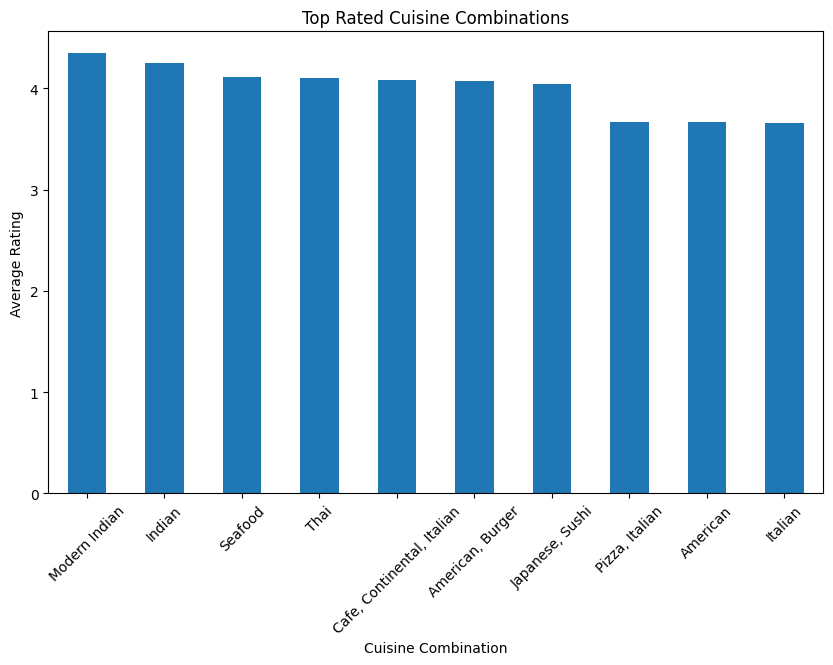

In [10]:
# Visualization of High Rated Cuisine Combinations
top_rated = popular.head(10)

top_rated['Average Rating'].plot(kind='bar', figsize=(10,6))

plt.title("Top Rated Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.show()

In [11]:
# Split Individual Cuisines
"North Indian, Chinese"

'North Indian, Chinese'

In [12]:
all_cuisines = df['Cuisines'].str.split(', ')

from collections import Counter

cuisine_counter = Counter()

for cuisines in all_cuisines:
    cuisine_counter.update(cuisines)

print(cuisine_counter.most_common(10))

[('North Indian', 3960), ('Chinese', 2735), ('Fast Food', 1986), ('Mughlai', 995), ('Italian', 764), ('Bakery', 745), ('Continental', 736), ('Cafe', 703), ('Desserts', 653), ('South Indian', 636)]


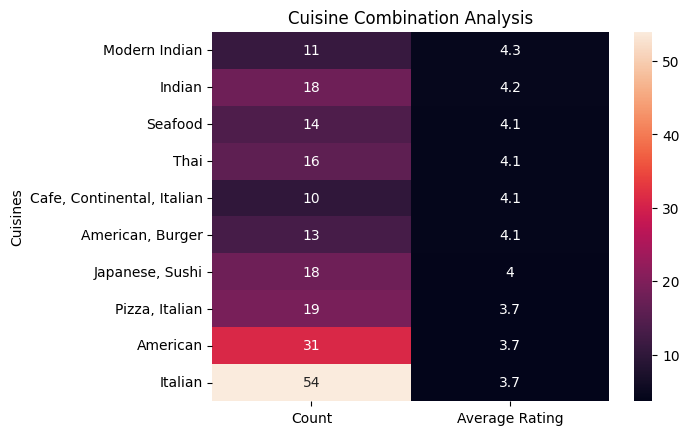

In [13]:
# Shows relationship between cuisine count and ratings.
import seaborn as sns

top = popular.head(10)

sns.heatmap(top[['Count', 'Average Rating']], annot=True)

plt.title("Cuisine Combination Analysis")
plt.show()

In [14]:
# Find Best Cuisine Combination
best = popular.sort_values(
    by='Average Rating',
    ascending=False
).head(1)

print(best)

               Count  Average Rating
Cuisines                            
Modern Indian     11        4.345455


In [15]:
# Export Results
result.to_csv("Cuisine_Combination_Analysis.csv")